# 5. Анализ ошибок (Error Analysis)
В этом ноутбуке мы оценим качество лучшей модели, посмотрим, где она ошибается сильнее всего, и проанализируем важность признаков.

In [1]:
import sys
sys.path.append("..")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

# Настройки графиков
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [2]:
# Вспомогательные функции
def categorical_without_description(X_df: pd.DataFrame) -> list[str]:
    cat_cols = X_df.select_dtypes(include=["object", "category"]).columns.tolist()
    return [col for col in cat_cols if col != "description"]

def numeric_columns(X_df: pd.DataFrame) -> list[str]:
    return X_df.select_dtypes(exclude=["object", "category"]).columns.tolist()

# Загружаем данные
data_path = Path("../data/interim/train_filtered.csv")
df = pd.read_csv(data_path, index_col=0)

y = df["price"].copy()
X = df.drop(columns=["price"]).copy()

# Загружаем лучшую модель

# Вспомогательные функции для пайплайна (нужны для загрузки модели)
def categorical_without_description(X_df: pd.DataFrame) -> list[str]:
    pass

def numeric_columns(X_df: pd.DataFrame) -> list[str]:
    pass

model_path = Path("../data/interim/best_model_pipeline.pkl")
best_pipe = joblib.load(model_path)

# Сделаем предсказания на всём train, так как мы хотим проанализировать характер ошибок
# (в реальной задаче анализ лучше делать на validation set, сделаем сплит)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
y_pred_val = best_pipe.predict(X_val)

mae = mean_absolute_error(y_val, y_pred_val)
mape = mean_absolute_percentage_error(y_val, y_pred_val)
print(f"Validation MAE: {mae:.2f}")
print(f"Validation MAPE: {mape:.2f}")

Validation MAE: 4695.40
Validation MAPE: 0.44


In [3]:
# Собираем DataFrame с предсказаниями и ошибками
val_results = X_val.copy()
val_results["actual_price"] = y_val
val_results["predicted_price"] = y_pred_val
val_results["abs_error"] = np.abs(y_val - y_pred_val)
val_results["error"] = y_pred_val - y_val

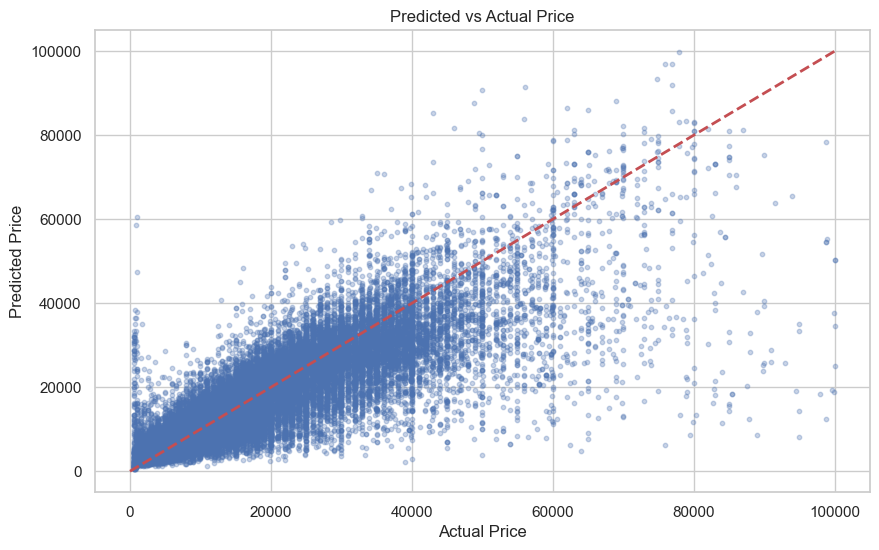

In [4]:
# 1. Распределение ошибок (Predicted vs Actual)
plt.figure(figsize=(10, 6))
plt.scatter(val_results["actual_price"], val_results["predicted_price"], alpha=0.3, s=10)
plt.plot([0, 100000], [0, 100000], 'r--', lw=2)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs Actual Price")
plt.show()

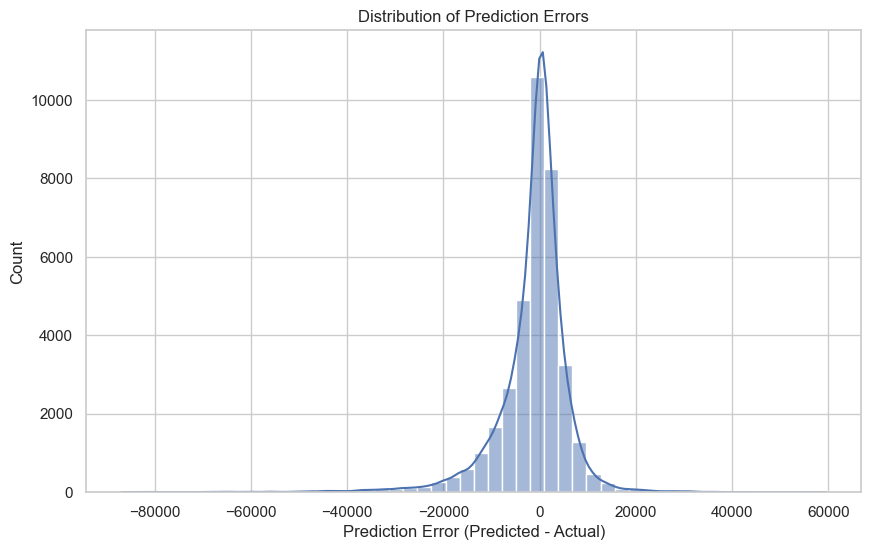

In [5]:
# 2. Гистограмма ошибок
plt.figure(figsize=(10, 6))
sns.histplot(val_results["error"], bins=50, kde=True)
plt.xlabel("Prediction Error (Predicted - Actual)")
plt.title("Distribution of Prediction Errors")
plt.show()

In [6]:
# 3. Где модель ошибается сильнее? (Топ-20 самых больших ошибок)
top_errors = val_results.sort_values(by="abs_error", ascending=False).head(20)
top_errors[["year", "manufacturer", "odometer", "actual_price", "predicted_price", "abs_error"]]

,year,manufacturer,odometer,actual_price,predicted_price,abs_error
132350,1981.0,jeep,50.0,95000,8041.773573,86958.226427
143516,2013.0,toyota,89000.0,98772,12509.115478,86262.884522
147063,2016.0,mercedes-benz,34529.0,99991,18813.411110,81177.588890
166660,2011.0,NaN,34000.0,94999,14434.655385,80564.344615
24001,1994.0,mercedes-benz,107000.0,89000,8569.128059,80430.871941
120779,2006.0,NaN,10000.0,99700,19406.735271,80293.264729
33463,2021.0,chevrolet,5.0,98000,18345.288681,79654.711319
106012,1997.0,porsche,19000.0,87888,12409.911591,75478.088409
111652,2008.0,NaN,22000.0,94500,19022.481481,75477.518519
152165,2015.0,jeep,15944.0,99999,25096.295803,74902.704197


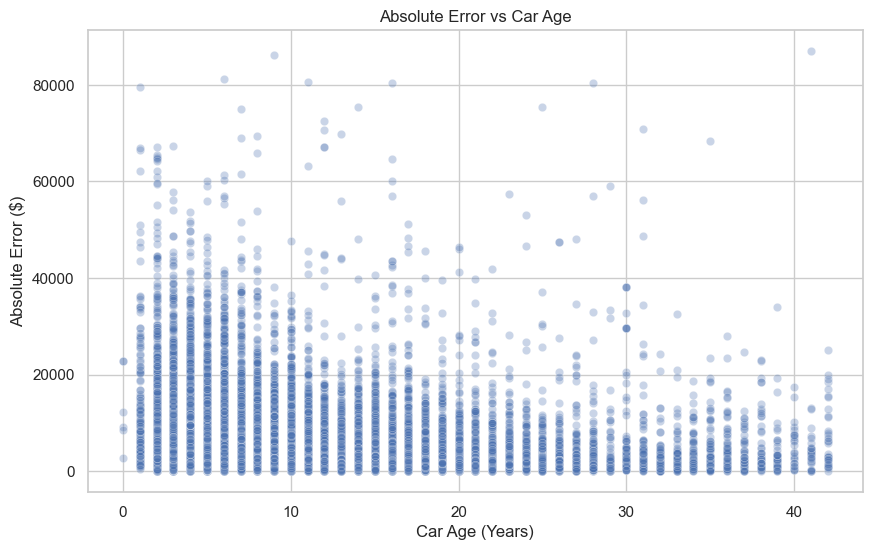

In [7]:
# 4. Анализ ошибок по возрасту автомобиля
# Создадим признак car_age для анализа
val_results["car_age"] = 2022 - val_results["year"]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=val_results, x="car_age", y="abs_error", alpha=0.3)
plt.title("Absolute Error vs Car Age")
plt.xlabel("Car Age (Years)")
plt.ylabel("Absolute Error ($)")
plt.show()

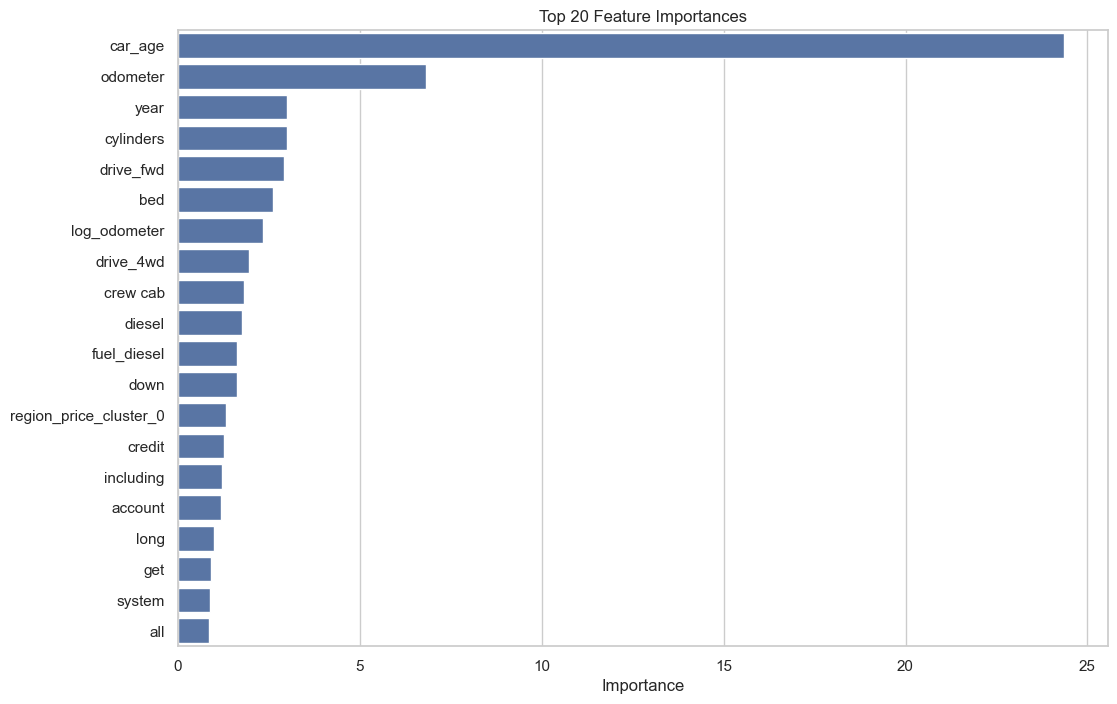

In [8]:
# 5. Важность признаков (Feature Importance)
# Извлечем имена колонок и важности из пайплайна
preprocessor = best_pipe.named_steps["prep"].named_steps["preprocess"]
encoder = best_pipe.named_steps["prep"].named_steps["encode"]
regressor_model = best_pipe.named_steps["model"].regressor_

# Получаем названия признаков после кодирования
tfidf_features = encoder.named_transformers_["description_tfidf"].get_feature_names_out()
cat_features = encoder.named_transformers_["categorical_ohe"].get_feature_names_out()

# Для числовых признаков нужно понять их порядок после preprocessor. 
# Preprocessor сохраняет и добавляет фичи. Мы можем применить preprocessor к одной строке, чтобы получить колонки.
X_prep = preprocessor.transform(X_val.head(1))
num_cols_item = encoder.transformers_[2][2]
if callable(num_cols_item):
    num_cols = num_cols_item(X_prep)
else:
    num_cols = num_cols_item

all_feature_names = np.concatenate([tfidf_features, cat_features, num_cols])

# Получаем feature importances из модели (Random Forest или CatBoost или DT)
if hasattr(regressor_model, "feature_importances_"):
    importances = regressor_model.feature_importances_
    
    # Сортируем топ-20
    indices = np.argsort(importances)[::-1][:20]
    top_features = all_feature_names[indices]
    top_importances = importances[indices]
    
    plt.figure(figsize=(12, 8))
    sns.barplot(x=top_importances, y=top_features)
    plt.title("Top 20 Feature Importances")
    plt.xlabel("Importance")
    plt.show()
else:
    print("Модель не поддерживает feature_importances_ напрямую.")